# 02 — Momentum 12-1 Factor

## Objective

The objective of this notebook is to construct the monthly momentum 12-1 factor
for the fixed universe of European equities.

For each stock and each month, the score is based on past monthly performance
over a rolling window, while excluding the most recent month.

We then rank the stocks cross-sectionally every month.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Monthly Returns

We load the monthly return matrix created in `01_data.ipynb`.

This keeps the workflow consistent:
- notebook 01 prepares and cleans the data
- notebook 02 uses the cleaned monthly returns to construct the momentum factor

In [2]:
monthly_returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)
monthly_returns.head()

print("Monthly returns shape:", monthly_returns.shape)
print("Start date:", monthly_returns.index.min())
print("End date:", monthly_returns.index.max())

Monthly returns shape: (191, 24)
Start date: 2010-02-28 00:00:00
End date: 2025-12-31 00:00:00


## 2. Definition of Momentum 12-1

At month t, the momentum 12-1 score is computed using returns from t-12 to t-2,
while excluding the most recent month t-1.

This means that the signal is based on 11 monthly returns.

The exclusion of the most recent month follows the standard momentum convention
and helps reduce short-term reversal effects.

In [3]:
# Exclude the most recent month from the signal
# shift(1) moves returns down by one row, so that month t does not use the most recent available return
shifted_returns = monthly_returns.shift(1)

# Compute the compounded momentum score over the previous 11 usable monthly returns
# Formula: (1 + r_1)(1 + r_2)...(1 + r_11) - 1
# rolling(window=11) defines the 11-month historical window
# np.prod multiplies all monthly gross returns inside the window
momentum_score = (1 + shifted_returns).rolling(window=11).apply(np.prod, raw=True) - 1

momentum_score.head(15)

,AD.AS,AIR.PA,ALV.DE,ASML.AS,BAS.DE,BBVA.MC,BNP.PA,ENEL.MI,ENI.MI,IBE.MC,...,NESN.SW,NOVN.SW,PHIA.AS,ROG.SW,SAN.MC,SAN.PA,SAP.DE,SIE.DE,UBSG.SW,UCG.MI
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Why This Formula?

We use compounded returns instead of a simple sum because investment performance is multiplicative through time.

For a stock with monthly returns r1, r2, ..., rn, the cumulative performance is:

\[
(1+r_1)(1+r_2)\cdots(1+r_n) - 1
\]

This provides a more accurate measure of medium-term past performance.

In [4]:
print("Momentum score shape:", momentum_score.shape)
print("\nMissing values by ticker:")
print(momentum_score.isna().sum().sort_values(ascending=False))

Momentum score shape: (191, 24)

Missing values by ticker:
AD.AS      11
AIR.PA     11
ALV.DE     11
ASML.AS    11
BAS.DE     11
BBVA.MC    11
BNP.PA     11
ENEL.MI    11
ENI.MI     11
IBE.MC     11
INGA.AS    11
ISP.MI     11
ITX.MC     11
MC.PA      11
NESN.SW    11
NOVN.SW    11
PHIA.AS    11
ROG.SW     11
SAN.MC     11
SAN.PA     11
SAP.DE     11
SIE.DE     11
UBSG.SW    11
UCG.MI     11
dtype: int64


## Interpretation of Missing Values

Missing values at the beginning of the factor series are normal.

The momentum 12-1 score requires:
- one month to exclude the most recent return
- eleven usable monthly returns to build the rolling window

As a result, the first months of the sample do not have enough history
to produce a valid momentum score.



## 3. Cross-Sectional Monthly Ranking

Each month, stocks are ranked according to their momentum score.

A higher score means stronger past medium-term performance.
The highest momentum stock receives rank 1.

In [5]:
# Rank stocks cross-sectionally each month
# axis=1 → ranking across stocks for each date
# ascending=False → highest momentum gets rank 1
momentum_rank = momentum_score.rank(axis=1, ascending=False, method="min")

# Remove initial periods with no valid momentum values
momentum_rank_clean = momentum_rank.dropna(how="all")

# Convert ranking to integers for readability
momentum_rank_clean = momentum_rank_clean.astype(int)

momentum_rank_clean.head(15)

,AD.AS,AIR.PA,ALV.DE,ASML.AS,BAS.DE,BBVA.MC,BNP.PA,ENEL.MI,ENI.MI,IBE.MC,...,NESN.SW,NOVN.SW,PHIA.AS,ROG.SW,SAN.MC,SAN.PA,SAP.DE,SIE.DE,UBSG.SW,UCG.MI
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-31,10,6,8,4,2,24,18,15,14,17,...,9,16,12,21,20,19,7,3,11,22
2011-02-28,13,4,9,5,3,17,16,14,11,12,...,20,23,15,24,18,22,6,1,10,19
2011-03-31,15,1,8,7,2,20,14,9,10,13,...,16,19,17,24,18,21,5,3,12,23
2011-04-30,20,1,9,6,2,19,13,10,11,12,...,15,17,22,24,18,14,8,3,16,21
2011-05-31,22,8,7,12,1,15,13,3,9,11,...,18,20,24,23,16,17,10,5,14,21
2011-06-30,21,7,10,11,1,19,9,2,13,5,...,17,16,24,18,20,14,12,8,15,23
2011-07-31,18,5,12,15,1,21,16,6,11,9,...,17,14,23,13,19,4,8,3,20,24
2011-08-31,16,3,9,5,1,20,17,10,13,14,...,15,18,22,11,19,7,6,4,23,24
2011-09-30,16,1,14,2,4,20,19,13,12,11,...,9,15,22,5,18,6,7,10,21,24


## 4. Sample Check on One Month

We inspect one sample month to verify that:
- top-ranked stocks have high momentum scores
- bottom-ranked stocks have low momentum scores

This is a consistency check before portfolio construction.

In [6]:
sample_date = momentum_score.dropna(how="all").index[20]
print("Sample date:", sample_date)


sample_scores = momentum_score.loc[sample_date].sort_values(ascending=False)

print("Top 5 stocks on sample date:")
print(sample_scores.head(5))

print("\nBottom 5 stocks on sample date:")
print(sample_scores.tail(5))

Sample date: 2012-09-30 00:00:00
Top 5 stocks on sample date:
ASML.AS    0.747520
AIR.PA     0.454888
PHIA.AS    0.420082
ITX.MC     0.409756
SAP.DE     0.400384
Name: 2012-09-30 00:00:00, dtype: float64

Bottom 5 stocks on sample date:
SAN.MC     0.023688
UBSG.SW    0.022282
ENEL.MI   -0.129622
IBE.MC    -0.324989
UCG.MI    -0.404410
Name: 2012-09-30 00:00:00, dtype: float64


## 5. Heatmap of Momentum Scores

We visualize recent momentum scores to check that the factor
creates meaningful cross-sectional differences across stocks and over time.

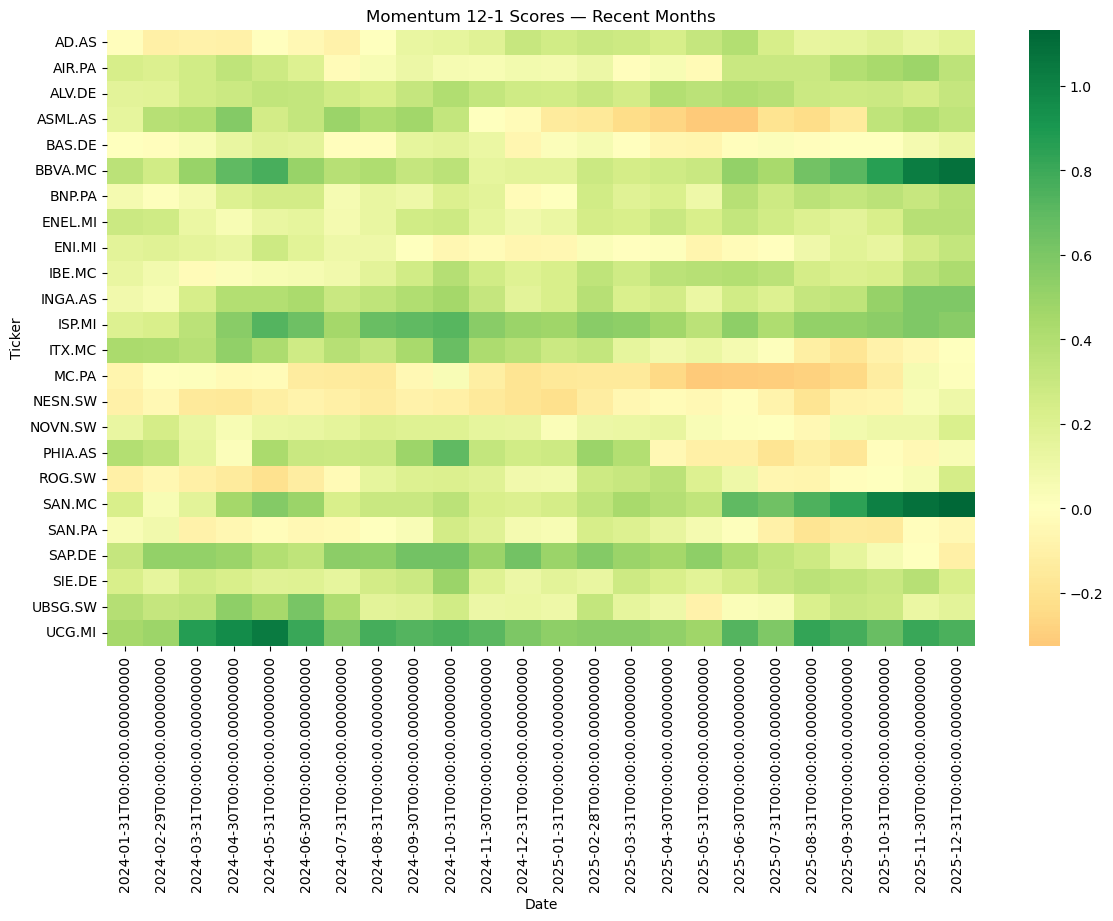

In [7]:
# Keep only the last 24 months for readability
heatmap_data = momentum_score.dropna(how="all").tail(24)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data.T, cmap="RdYlGn", center=0)
plt.title("Momentum 12-1 Scores — Recent Months")
plt.xlabel("Date")
plt.ylabel("Ticker")
plt.show()

## 6. Save Factor Outputs

We save the factor outputs to the `data/` folder
so they can be reused in the backtest notebook.

In [8]:
momentum_score.to_csv("../data/momentum_score.csv")
momentum_rank.to_csv("../data/momentum_rank.csv")

print("Files saved successfully:")
print("- ../data/momentum_score.csv")
print("- ../data/momentum_rank.csv")

Files saved successfully:
- ../data/momentum_score.csv
- ../data/momentum_rank.csv


## Conclusion

In this notebook, we constructed the momentum 12-1 factor:

- monthly returns were transformed into rolling momentum scores
- the most recent month was excluded from the signal
- stocks were ranked every month based on their score
- a sample check and a heatmap confirmed that the ranking is coherent

These rankings will be used in the next notebook
to build the monthly momentum portfolio.